# EmporiUm Sales Territory Analysis

## Capstone 2: Business Analysis with Python

**Assigned territories:** Massachusetts and New Jersey  
**Region:** Northeast

This notebook analyzes in-store sales performance for the assigned territories using pandas, NumPy, and Matplotlib.

## Step 1: Import Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


## Step 2: Load CSV Files

All CSV files should be in the same folder as this notebook.

In [2]:

store_sales = pd.read_csv('StoreSales.csv')
store_sales.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  object 
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  object 
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 12.8+ MB


In [3]:
store_sales.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


In [4]:

store_detail = pd.read_csv('StoreDetail.csv')
store_detail.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Store Location     111 non-null    object
 1   State              111 non-null    object
 2   Store ID           111 non-null    int64 
 3   Territory Manager  111 non-null    object
 4   Region             111 non-null    object
 5   Region Director    111 non-null    object
dtypes: int64(1), object(5)
memory usage: 5.3+ KB


In [5]:
store_detail.head()

,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


In [6]:

products = pd.read_csv('Products.csv')
products.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Prod Num       669 non-null    object
 1   Product        669 non-null    object
 2   CategoryID     669 non-null    int64 
 3   SubcategoryID  669 non-null    object
dtypes: int64(1), object(3)
memory usage: 21.0+ KB


In [7]:
products.head()

,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


In [8]:

product_categories = pd.read_csv('ProductCategories.csv')
product_categories.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CategoryID     52 non-null     int64 
 1   Category       52 non-null     object
 2   SubcategoryID  52 non-null     object
 3   Subcategory    52 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.8+ KB


In [9]:
product_categories.head()

,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


In [10]:

# customer_list.csv is pipe-separated, so sep='|' is required.
customers = pd.read_csv('customer_list.csv', sep='|')
customers.columns = customers.columns.str.strip()
customers.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   cust_id      521 non-null    int64 
 1   date         521 non-null    object
 2   time         521 non-null    object
 3   name         521 non-null    object
 4   email        521 non-null    object
 5   phone        520 non-null    object
 6   sms-opt-out  520 non-null    object
dtypes: int64(1), object(6)
memory usage: 28.6+ KB


In [11]:
customers.head()

,cust_id,date,time,name,email,phone,sms-opt-out
0,1,2023-03-15,08:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,2023-05-22,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,2023-07-09,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
3,4,2023-09-01,21:05:33,Chandler Bing,chandlerb@centralperk.coffee,212-555-1004,Y
4,5,2023-11-18,14:22:10,Joey,howyoudoing@centralperk.coffee,212-555-1005,N


## Step 3: Clean and Merge Data

In [12]:

# Clean dates and IDs
store_sales['Transaction Date'] = pd.to_datetime(store_sales['Transaction Date'])
store_sales['Month'] = store_sales['Transaction Date'].dt.to_period('M').astype(str)
store_sales['RewardsID'] = pd.to_numeric(store_sales['RewardsID'], errors='coerce')
customers['cust_id'] = pd.to_numeric(customers['cust_id'], errors='coerce')

# Merge sales with store details
sales_store = pd.merge(
    store_sales,
    store_detail,
    on='Store ID',
    how='left'
)

# Filter to assigned territories/states
assigned_states = ['Massachusetts', 'New Jersey']
territory_sales = sales_store[sales_store['State'].isin(assigned_states)].copy()

territory_sales.head()


,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Month,Store Location,State,Territory Manager,Region,Region Director
79,2022-01-01,803,NaN,105422-T,116.20,2022-01,Framingham,Massachusetts,Bo Heap,Northeast,Michael Jarvis
80,2022-01-01,803,NaN,105423-M,40.55,2022-01,Framingham,Massachusetts,Bo Heap,Northeast,Michael Jarvis
81,2022-01-01,804,NaN,105424-T,192.26,2022-01,Haverhill,Massachusetts,Bo Heap,Northeast,Michael Jarvis
82,2022-01-01,806,NaN,105345-IT,120.82,2022-01,Holyoke,Massachusetts,Bo Heap,Northeast,Michael Jarvis
83,2022-01-01,806,186.00,105385-M,27.52,2022-01,Holyoke,Massachusetts,Bo Heap,Northeast,Michael Jarvis


In [14]:

# Merge product and category information for territory sales
sales_products = pd.merge(
    territory_sales,
    products,
    on='Prod Num',
    how='left'
)

full_sales = pd.merge(
    sales_products,
    product_categories,
    on=['CategoryID', 'SubcategoryID'],
    how='left'
)

full_sales.head()


,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Month,Store Location,State,Territory Manager,Region,Region Director,Product,CategoryID,SubcategoryID,Category,Subcategory
0,2022-01-01,803,NaN,105422-T,116.20,2022-01,Framingham,Massachusetts,Bo Heap,Northeast,Michael Jarvis,Abstract Algebra,100,100-mat,Textbooks,Math and Statistics
1,2022-01-01,803,NaN,105423-M,40.55,2022-01,Framingham,Massachusetts,Bo Heap,Northeast,Michael Jarvis,"LTCA Year Up Coasters (Set of 4, Cork)",130,130-hom,Apparel and Merchandise,Home and Decor
2,2022-01-01,804,NaN,105424-T,192.26,2022-01,Haverhill,Massachusetts,Bo Heap,Northeast,Michael Jarvis,Organic Chemistry I,100,100-sci,Textbooks,Science
3,2022-01-01,806,NaN,105345-IT,120.82,2022-01,Holyoke,Massachusetts,Bo Heap,Northeast,Michael Jarvis,Razer Kraken X,120,120-hea,Technology & Accessories,Headphones
4,2022-01-01,806,186.00,105385-M,27.52,2022-01,Holyoke,Massachusetts,Bo Heap,Northeast,Michael Jarvis,LTCA Year Up Foam Finger (Black),130,130-spo,Apparel and Merchandise,Sports and Outdoor Gear


# Core Marketing Analysis

## 1. Territory Managers, Store IDs, and Cities

In [15]:

territory_info = store_detail[store_detail['State'].isin(assigned_states)][
    ['State', 'Territory Manager', 'Region', 'Region Director', 'Store ID', 'Store Location']
].sort_values(['State', 'Store ID'])

territory_info


,State,Territory Manager,Region,Region Director,Store ID,Store Location
52,Massachusetts,Bo Heap,Northeast,Michael Jarvis,730,Boston
53,Massachusetts,Bo Heap,Northeast,Michael Jarvis,801,Attleboro
54,Massachusetts,Bo Heap,Northeast,Michael Jarvis,802,Falmouth
55,Massachusetts,Bo Heap,Northeast,Michael Jarvis,803,Framingham
56,Massachusetts,Bo Heap,Northeast,Michael Jarvis,804,Haverhill
57,Massachusetts,Bo Heap,Northeast,Michael Jarvis,805,Hingham
58,Massachusetts,Bo Heap,Northeast,Michael Jarvis,806,Holyoke
59,Massachusetts,Bo Heap,Northeast,Michael Jarvis,807,Leominster
60,Massachusetts,Bo Heap,Northeast,Michael Jarvis,808,Lowell
61,Massachusetts,Bo Heap,Northeast,Michael Jarvis,809,Lynn


## 2. Monthly Total Revenue by Territory

In [16]:

monthly_revenue = territory_sales.groupby(['State', 'Month'], as_index=False)['Sale Amount'].sum()
monthly_revenue = monthly_revenue.sort_values(['State', 'Month'])
monthly_revenue


,State,Month,Sale Amount
0,Massachusetts,2022-01,"69,396.42"
1,Massachusetts,2022-02,"65,616.00"
2,Massachusetts,2022-03,"77,390.00"
3,Massachusetts,2022-04,"81,333.60"
4,Massachusetts,2022-05,"75,919.64"
...,...,...,...
91,New Jersey,2025-08,"151,923.99"
92,New Jersey,2025-09,"163,449.78"
93,New Jersey,2025-10,"250,830.46"
94,New Jersey,2025-11,"146,953.33"


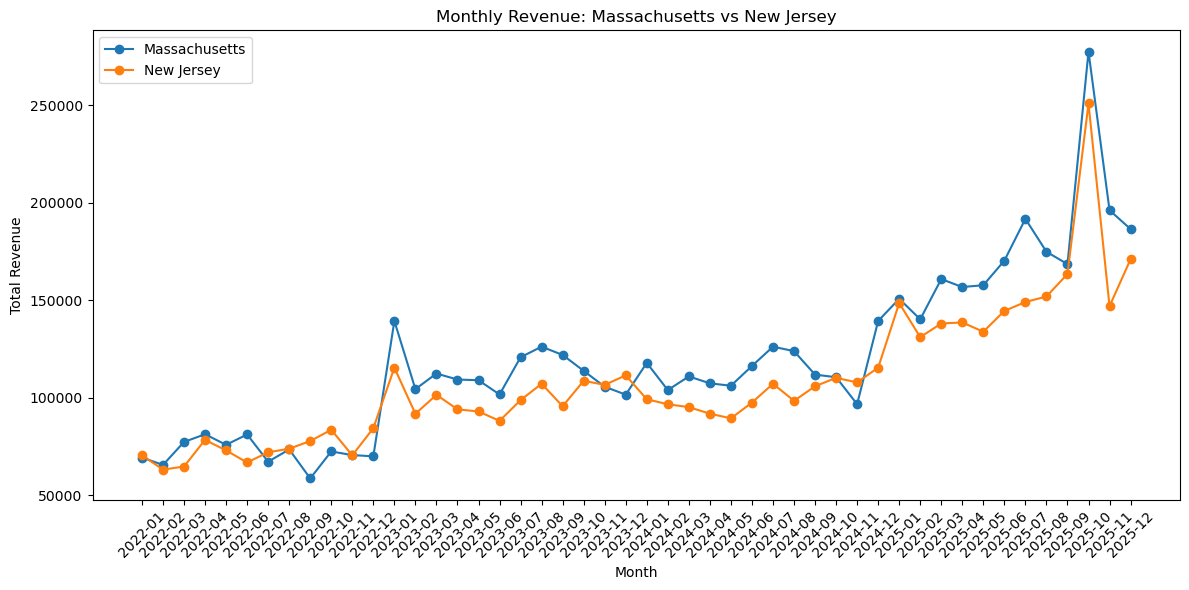

In [17]:

plt.figure(figsize=(12, 6))

for state in assigned_states:
    state_data = monthly_revenue[monthly_revenue['State'] == state]
    plt.plot(state_data['Month'], state_data['Sale Amount'], marker='o', label=state)

plt.title('Monthly Revenue: Massachusetts vs New Jersey')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## 3. Store Performance Rankings

In [18]:

store_performance = territory_sales.groupby(
    ['State', 'Store ID', 'Store Location'], as_index=False
).agg(
    Total_Revenue=('Sale Amount', 'sum'),
    Transactions=('Sale Amount', 'count'),
    Average_Sale=('Sale Amount', 'mean')
).sort_values(['State', 'Total_Revenue'], ascending=[True, False])

store_performance


,State,Store ID,Store Location,Total_Revenue,Transactions,Average_Sale
17,Massachusetts,817,Worcester,"602,183.44",4477,134.51
7,Massachusetts,807,Leominster,"338,009.10",2293,147.41
10,Massachusetts,810,Nantucket,"335,547.81",2272,147.69
14,Massachusetts,814,Provincetown,"328,860.51",2310,142.36
12,Massachusetts,812,Northampton,"322,039.24",2258,142.62
6,Massachusetts,806,Holyoke,"320,516.53",2168,147.84
16,Massachusetts,816,Somerville,"312,873.59",2174,143.92
4,Massachusetts,804,Haverhill,"305,762.60",2287,133.70
9,Massachusetts,809,Lynn,"302,049.65",2118,142.61
13,Massachusetts,813,Pittsfield,"301,281.50",2172,138.71


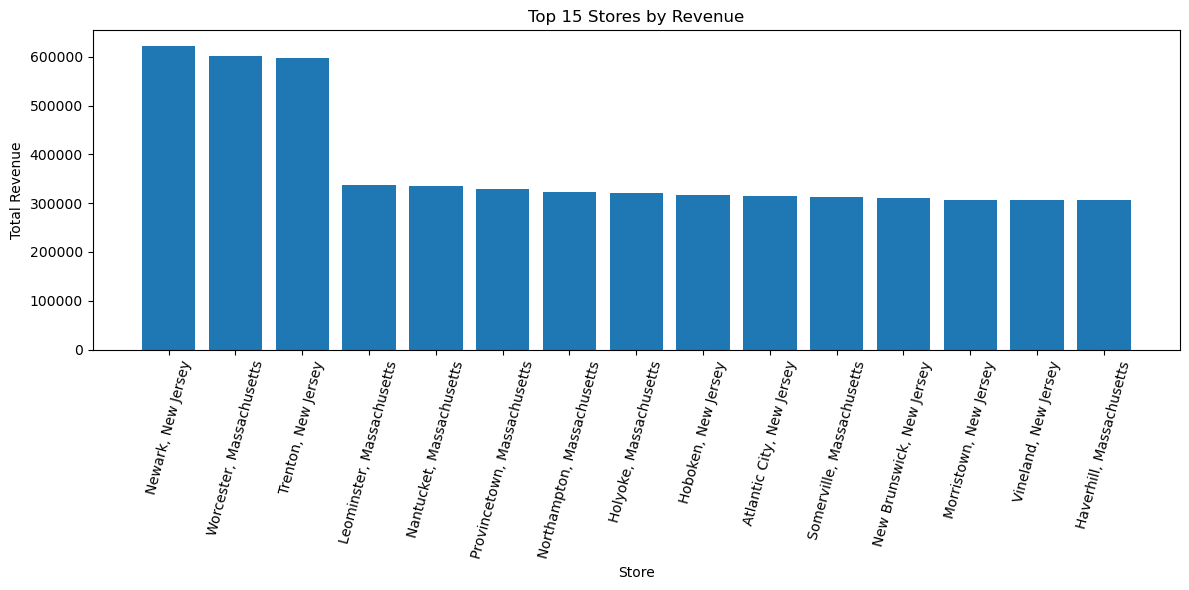

In [19]:

plt.figure(figsize=(12, 6))

store_chart = store_performance.sort_values('Total_Revenue', ascending=False).head(15)
plt.bar(store_chart['Store Location'] + ', ' + store_chart['State'], store_chart['Total_Revenue'])

plt.title('Top 15 Stores by Revenue')
plt.xlabel('Store')
plt.ylabel('Total Revenue')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


## 4. Top Rewards Customers in Each Territory

In [20]:

customer_sales = pd.merge(
    territory_sales,
    customers,
    left_on='RewardsID',
    right_on='cust_id',
    how='left'
)

top_customers = customer_sales.dropna(subset=['cust_id']).groupby(
    ['State', 'cust_id', 'name', 'email'], as_index=False
).agg(
    Total_Spent=('Sale Amount', 'sum'),
    Transactions=('Sale Amount', 'count')
).sort_values(['State', 'Total_Spent'], ascending=[True, False])

top_customers.groupby('State').head(10)


,State,cust_id,name,email,Total_Spent,Transactions
291,Massachusetts,292.00,Beverly Crusher,crusher@enterprise.starfleet,"4,758.92",14
383,Massachusetts,384.00,Tracy Jordan,tracy@tgs.nbc,"4,197.55",14
46,Massachusetts,47.00,Stanley H.,stanley@dundermifflin.com,"3,979.73",12
2,Massachusetts,3.00,Monica Geller,chefmonica@centralperk.coffee,"3,966.91",15
187,Massachusetts,188.00,Mellie Grant,mellie@oliviapopeandassociates.com,"3,948.41",10
299,Massachusetts,300.00,Julian Bashir,bashir@ds9.starfleet,"3,883.60",12
16,Massachusetts,17.00,Mike E.,mike@lospolloshermanos.biz,"3,788.67",11
315,Massachusetts,316.00,Kaylee Frye,kaylee@serenity.ship,"3,725.87",13
343,Massachusetts,344.00,Nate Jacobs,nate@easthighland.high,"3,569.36",10
177,Massachusetts,178.00,Pamela James,pam@wzhup.det,"3,523.01",12


## 5. Product Category Transactions and Revenue by Month

In [21]:

category_monthly = full_sales.groupby(
    ['State', 'Month', 'Category'], as_index=False
).agg(
    Transactions=('Sale Amount', 'count'),
    Total_Revenue=('Sale Amount', 'sum')
).sort_values(['State', 'Month', 'Category'])

category_monthly


,State,Month,Category,Transactions,Total_Revenue
0,Massachusetts,2022-01,Apparel and Merchandise,83,"3,008.15"
1,Massachusetts,2022-01,Art Supplies,111,"3,464.11"
2,Massachusetts,2022-01,Books (General),41,"1,062.65"
3,Massachusetts,2022-01,Stationery and Supplies,106,"1,138.12"
4,Massachusetts,2022-01,Technology & Accessories,112,"48,949.88"
...,...,...,...,...,...
571,New Jersey,2025-12,Art Supplies,220,"7,403.37"
572,New Jersey,2025-12,Books (General),78,"1,932.69"
573,New Jersey,2025-12,Stationery and Supplies,227,"2,307.96"
574,New Jersey,2025-12,Technology & Accessories,281,"131,024.14"


In [22]:

category_totals = full_sales.groupby(['State', 'Category'], as_index=False).agg(
    Transactions=('Sale Amount', 'count'),
    Total_Revenue=('Sale Amount', 'sum')
).sort_values(['State', 'Total_Revenue'], ascending=[True, False])

category_totals


,State,Category,Transactions,Total_Revenue
4,Massachusetts,Technology & Accessories,8724,"4,059,863.21"
5,Massachusetts,Textbooks,5789,"998,901.78"
0,Massachusetts,Apparel and Merchandise,8314,"266,531.69"
1,Massachusetts,Art Supplies,7865,"246,064.01"
2,Massachusetts,Books (General),3409,"99,532.89"
3,Massachusetts,Stationery and Supplies,9019,"91,211.24"
10,New Jersey,Technology & Accessories,7883,"3,630,738.42"
11,New Jersey,Textbooks,5419,"936,799.67"
6,New Jersey,Apparel and Merchandise,7353,"237,281.41"
7,New Jersey,Art Supplies,7162,"225,414.36"


<Figure size 1000x600 with 0 Axes>

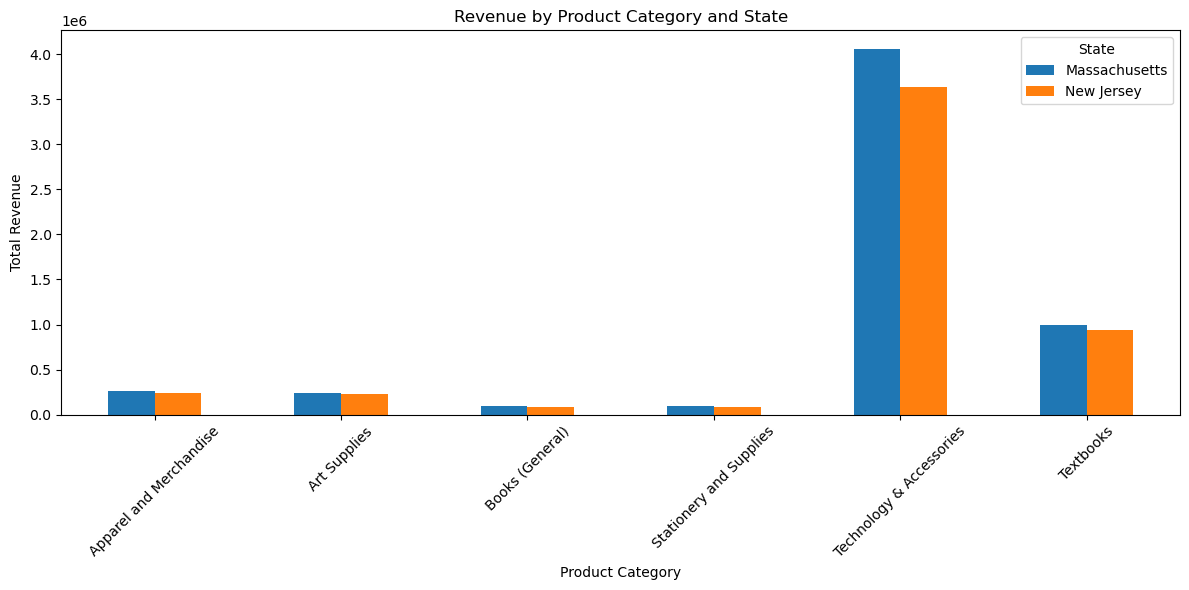

In [23]:

plt.figure(figsize=(10, 6))

category_by_state = category_totals.pivot(index='Category', columns='State', values='Total_Revenue').fillna(0)
category_by_state.plot(kind='bar', figsize=(12, 6))

plt.title('Revenue by Product Category and State')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 6. Marketing Recommendation

Based on the analysis, marketing attention should focus on the strongest revenue categories and the stores with room for growth in Massachusetts and New Jersey. Massachusetts is managed by **Bo Heap**, while New Jersey is managed by **Miami Vue**. Both states are part of the **Northeast** region under **Michael Jarvis**.

Recommended next steps:

1. Use high-performing product categories as the center of the next campaign.
2. Promote loyalty/rewards campaigns to increase repeat customer spending.
3. Compare lower-performing stores against top stores to identify where local marketing support is needed.
4. Use monthly revenue trends to time promotions around stronger buying periods.

The clearest opportunity is to combine product-category marketing with customer rewards targeting so that EmporiUm can increase both transaction count and average customer spend.

# Bonus Analysis Starter

In [24]:

# January 2024 transactions over $500 in assigned territories
january_2024 = territory_sales[
    (territory_sales['Transaction Date'].dt.year == 2024) &
    (territory_sales['Transaction Date'].dt.month == 1)
].sort_values('Sale Amount', ascending=False)

january_2024_over_500 = january_2024[january_2024['Sale Amount'] > 500]
january_2024_over_500.head()


,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Month,Store Location,State,Territory Manager,Region,Region Director
138658,2024-01-26,836,NaN,105326-IT,"1,717.70",2024-01,Passaic,New Jersey,Miami Vue,Northeast,Michael Jarvis
139097,2024-01-28,838,NaN,105325-IT,"1,717.70",2024-01,Trenton,New Jersey,Miami Vue,Northeast,Michael Jarvis
139489,2024-01-30,817,NaN,105325-IT,"1,717.70",2024-01,Worcester,Massachusetts,Bo Heap,Northeast,Michael Jarvis
135043,2024-01-09,806,NaN,105326-IT,"1,717.70",2024-01,Holyoke,Massachusetts,Bo Heap,Northeast,Michael Jarvis
138869,2024-01-27,827,NaN,105326-IT,"1,717.70",2024-01,Clifton,New Jersey,Miami Vue,Northeast,Michael Jarvis


In [25]:

# Top 10 products by total revenue in assigned territories
top_products = full_sales.groupby(['Prod Num', 'Product'], as_index=False).agg(
    Total_Revenue=('Sale Amount', 'sum'),
    Transactions=('Sale Amount', 'count')
).sort_values('Total_Revenue', ascending=False)

top_products.head(10)


,Prod Num,Product,Total_Revenue,Transactions
78,105326-IT,"Apple MacBook Air (M2, 13-inch)","261,090.40",152
93,105341-IT,MSI Creator Z16,"259,263.90",147
77,105325-IT,"Apple MacBook Pro (M2, 14-inch)","252,501.90",147
84,105332-IT,HP Spectre x360,"237,682.40",190
85,105333-IT,ASUS VivoBook S15,"235,144.00",182
83,105331-IT,Acer Chromebook Spin 713,"227,796.80",176
90,105338-IT,Dell Inspiron 15,"218,738.20",166
89,105337-IT,HP Pavilion 14,"217,413.96",167
86,105334-IT,Samsung Galaxy Book Pro,"211,723.04",166
87,105335-IT,Lenovo Yoga 7i,"204,910.56",163
